In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from probcs.models.pattern_completion_model import PatternCompletionModel, BinaryPatternCompletionModel
from probcs.experiment_running.exc_experiment import center_surround_experiment, create_stimuli
from probcs.utils.utils import load_images
from torchvision import transforms
import arviz as az
from sklearn.metrics.pairwise import cosine_similarity
from probcs.utils.utils import select_focus_images, get_excitatory_images
from probcs.utils.plotting import plot_posterior_binary
import pickle
import pandas as pd
import os
import glob

seed = 42
rng = np.random.default_rng(seed)

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [2]:
results_dict = {
    'stimulus_id': [],
    'big_stimulus': [],
    'small_x_mean': [],
    'small_g_mean': [],
    'big_x_mean': [],
    'big_g_mean': [],
}

# Find all small stimulus .pkl files in the results directory
small_pkl_files = glob.glob("results/coen_cagli_small_stimulus_*.pkl")
print(f"Found {len(small_pkl_files)} small stimulus .pkl files:")
for file in small_pkl_files:
    print(f"  {file}")

# Process each small stimulus .pkl file
for results_path in small_pkl_files:
    # Load the small stimulus pickle file
    with open(results_path, "rb") as f:
        results = pickle.load(f)
        X = results['posterior']['X'].data
        X_mean = X.mean((0, 1))
        G = results['posterior']['G'].data
        G_mean = G.mean((0, 1))
        
        # Extract ID from filename
        stimulus_id = int(results_path.split("_")[-1].strip(".pkl"))
        
        # Load corresponding small stimulus image file
        image_path = results_path.replace("small_stimulus", "big_stimulus").replace(".pkl", ".npy")
        with open(image_path, "rb") as f:
            image = np.load(f)
        
        # Load corresponding big stimulus results
        big_results_path = f"results/coen_cagli_big_stimulus_results_{stimulus_id}.pkl"
        with open(big_results_path, "rb") as f:
            big_results = pickle.load(f)
            big_X = big_results['posterior']['X'].data
            big_x_mean = big_X.mean((0, 1))
            big_G = big_results['posterior']['G'].data
            big_g_mean = big_G.mean((0, 1))
        
        # Append to results dictionary
        results_dict['stimulus_id'].append(stimulus_id)
        results_dict['big_stimulus'].append(image)
        results_dict['small_x_mean'].append(X_mean)
        results_dict['small_g_mean'].append(G_mean)
        results_dict['big_x_mean'].append(big_x_mean)
        results_dict['big_g_mean'].append(big_g_mean)
        
        print(f"Processed {results_path} with stimulus_id {stimulus_id}")

# Convert to pandas DataFrame
df = pd.DataFrame(results_dict)

# Add center mean columns
G_dim = 10
center_ids = list(range(G_dim*4, G_dim*4 + G_dim))  # [40, 41, 42, ..., 49]

print(f"Center IDs: {center_ids}")
print(f"This corresponds to indices {G_dim*4} to {G_dim*4 + G_dim - 1}")

# Extract the center region for each small_x_mean and compute its mean
df['small_x_center_mean'] = df['small_x_mean'].apply(lambda x: x[center_ids].mean())

# Extract the center region for each big_x_mean and compute its mean
df['big_x_center_mean'] = df['big_x_mean'].apply(lambda x: x[center_ids].mean())

Found 1000 small stimulus .pkl files:
  results/coen_cagli_small_stimulus_637.pkl
  results/coen_cagli_small_stimulus_792.pkl
  results/coen_cagli_small_stimulus_808.pkl
  results/coen_cagli_small_stimulus_578.pkl
  results/coen_cagli_small_stimulus_849.pkl
  results/coen_cagli_small_stimulus_145.pkl
  results/coen_cagli_small_stimulus_746.pkl
  results/coen_cagli_small_stimulus_285.pkl
  results/coen_cagli_small_stimulus_586.pkl
  results/coen_cagli_small_stimulus_500.pkl
  results/coen_cagli_small_stimulus_903.pkl
  results/coen_cagli_small_stimulus_701.pkl
  results/coen_cagli_small_stimulus_552.pkl
  results/coen_cagli_small_stimulus_200.pkl
  results/coen_cagli_small_stimulus_671.pkl
  results/coen_cagli_small_stimulus_790.pkl
  results/coen_cagli_small_stimulus_964.pkl
  results/coen_cagli_small_stimulus_442.pkl
  results/coen_cagli_small_stimulus_973.pkl
  results/coen_cagli_small_stimulus_352.pkl
  results/coen_cagli_small_stimulus_363.pkl
  results/coen_cagli_small_stimulus_33

In [3]:
df

,stimulus_id,big_stimulus,small_x_mean,small_g_mean,big_x_mean,big_g_mean,small_x_center_mean,big_x_center_mean
0,637,"[[15.239399030293532, 15.161983196569444, 15.2...","[0.32916666666666666, 0.04416666666666667, 0.2...","[0.36916666666666664, 0.025833333333333333, 0....","[0.36333333333333334, 0.2991666666666667, 0.05...","[0.415, 0.3175, 0.0, 0.12666666666666668, 0.75...",0.083083,0.199333
1,792,"[[6.829643283480405, 7.213035983828268, 7.5490...","[0.31583333333333335, 0.095, 0.0475, 0.0358333...","[0.36333333333333334, 0.07833333333333334, 0.0...","[0.08666666666666667, 0.15416666666666667, 0.0...","[0.0575, 0.1725, 0.08, 0.020833333333333332, 0...",0.126167,0.119000
2,808,"[[-9.989868210145852, -11.33450751256781, -10....","[0.24166666666666667, 0.041666666666666664, 0....","[0.25, 0.0, 0.0, 0.0, 0.28583333333333333, 0.5...","[0.1025, 0.050833333333333335, 0.2133333333333...","[0.06416666666666666, 0.018333333333333333, 0....",0.092583,0.101583
3,578,"[[-5.727389269980294, -5.4591987031504186, -5....","[0.245, 0.235, 0.049166666666666664, 0.0366666...","[0.24333333333333335, 0.25, 0.0, 0.0, 0.064166...","[0.25833333333333336, 0.13833333333333334, 0.0...","[0.2916666666666667, 0.1375, 0.06, 0.1775, 0.1...",0.087750,0.119833
4,849,"[[-8.031431940340056, -9.952081910351954, -11....","[0.24, 0.11083333333333334, 0.2375, 0.16, 0.09...","[0.24666666666666667, 0.10916666666666666, 0.2...","[0.10416666666666667, 0.059166666666666666, 0....","[0.07333333333333333, 0.041666666666666664, 0....",0.108750,0.085583
...,...,...,...,...,...,...,...,...
995,895,"[[14.202579828631642, 14.125163994907552, 14.3...","[0.04666666666666667, 0.029166666666666667, 0....","[0.0, 0.0, 0.035833333333333335, 0.5, 0.37, 0....","[0.22916666666666666, 0.13, 0.0391666666666666...","[0.26416666666666666, 0.09, 0.0, 0.40333333333...",0.091250,0.105083
996,700,"[[10.400909422538035, 10.208291455295958, 10.1...","[0.2758333333333333, 0.04, 0.0375, 0.055833333...","[0.30583333333333335, 0.0, 0.0, 0.0, 0.165, 0....","[0.09, 0.22583333333333333, 0.085, 0.216666666...","[0.05, 0.20666666666666667, 0.0475, 0.215, 0.3...",0.067000,0.103083
997,799,"[[-12.409113014023601, -12.48652884774769, -11...","[0.365, 0.0475, 0.056666666666666664, 0.2275, ...","[0.44166666666666665, 0.0175, 0.0, 0.228333333...","[0.085, 0.034166666666666665, 0.06333333333333...","[0.025833333333333333, 0.008333333333333333, 0...",0.091750,0.064250
998,487,"[[1.0695366075810018, 1.1073229073749007, 1.67...","[0.18833333333333332, 0.04083333333333333, 0.0...","[0.19166666666666668, 0.0, 0.0, 0.25, 0.103333...","[0.5058333333333334, 0.08916666666666667, 0.09...","[0.6083333333333333, 0.07416666666666667, 0.06...",0.075833,0.144250


In [ ]:
# Create a dictionary to store the top 200 stimulus IDs for each center neuron
top_activating_stimuli = {}

# For each center neuron
for i, center_neuron_idx in enumerate(center_ids):
    # Extract the activation values for this specific center neuron across all stimuli
    neuron_activations = df['small_x_mean'].apply(lambda x: x[center_neuron_idx])
    
    # Get the indices of the top 200 most activating stimuli
    top_200_indices = neuron_activations.nlargest(200).index
    
    # Get the corresponding stimulus IDs
    top_200_stimulus_ids = df.loc[top_200_indices, 'stimulus_id'].tolist()
    
    # Store in dictionary
    neuron_name = f'center_neuron_{i}'  # neuron 0-9
    top_activating_stimuli[neuron_name] = top_200_stimulus_ids
    
    print(f"Center neuron {i} (index {center_neuron_idx}): Top 200 stimulus IDs")
    print(f"  Max activation: {neuron_activations.max():.4f}")
    print(f"  Min activation in top 200: {neuron_activations.iloc[top_200_indices].min():.4f}")
    print(f"  Sample stimulus IDs: {top_200_stimulus_ids[:10]}")

print(f"Created dictionary with {len(top_activating_stimuli)} center neurons")
print(f"Each neuron has {len(top_activating_stimuli['center_neuron_0'])} top activating stimulus IDs")

Center neuron 0 (index 40): Top 200 stimulus IDs
  Max activation: 0.5267
  Min activation in top 200: 0.2875
  Sample stimulus IDs: [543, 889, 601, 304, 883, 800, 117, 372, 339, 111]
Center neuron 1 (index 41): Top 200 stimulus IDs
  Max activation: 0.3517
  Min activation in top 200: 0.1200
  Sample stimulus IDs: [436, 276, 452, 750, 746, 646, 795, 515, 53, 131]
Center neuron 2 (index 42): Top 200 stimulus IDs
  Max activation: 0.4117
  Min activation in top 200: 0.1183
  Sample stimulus IDs: [496, 386, 525, 162, 646, 323, 746, 424, 979, 824]
Center neuron 3 (index 43): Top 200 stimulus IDs
  Max activation: 0.3667
  Min activation in top 200: 0.0692
  Sample stimulus IDs: [471, 340, 338, 973, 817, 207, 261, 777, 233, 854]
Center neuron 4 (index 44): Top 200 stimulus IDs
  Max activation: 0.5908
  Min activation in top 200: 0.1958
  Sample stimulus IDs: [555, 850, 350, 393, 815, 4, 25, 697, 240, 565]
Center neuron 5 (index 45): Top 200 stimulus IDs
  Max activation: 0.4500
  Min acti

In [20]:
top_activating_stimuli

{'center_neuron_0': [543,
  889,
  601,
  304,
  883,
  800,
  117,
  372,
  339,
  111,
  546,
  947,
  652,
  218,
  574,
  145,
  90,
  740,
  841,
  395,
  880,
  938,
  634,
  135,
  73,
  976,
  324,
  366,
  541,
  998,
  917,
  866,
  7,
  441,
  933,
  84,
  829,
  130,
  888,
  956,
  192,
  179,
  342,
  737,
  499,
  826,
  943,
  877,
  229,
  937,
  596,
  840,
  705,
  217,
  174,
  951,
  955,
  210,
  163,
  212,
  454,
  878,
  333,
  946,
  95,
  417,
  328,
  870,
  453,
  413,
  612,
  722,
  9,
  223,
  142,
  68,
  193,
  294,
  437,
  194,
  610,
  205,
  572,
  364,
  235,
  497,
  220,
  822,
  703,
  402,
  18,
  265,
  397,
  975,
  88,
  742,
  173,
  274,
  954,
  391,
  586,
  58,
  896,
  1,
  431,
  94,
  881,
  501,
  838,
  919,
  825,
  971,
  99,
  104,
  912,
  711,
  148,
  439,
  374,
  119,
  427,
  979,
  170,
  306,
  359,
  687,
  189,
  296,
  51,
  614,
  605,
  195,
  983,
  361,
  763,
  421,
  196,
  300,
  103,
  799,
  714,
  984,
  49

In [9]:
# Create a more organized DataFrame for analysis
top_stimuli_data = []

for neuron_name, stimulus_ids in top_activating_stimuli.items():
    neuron_idx = int(neuron_name.split('_')[-1])  # Extract neuron index (0-9)
    center_neuron_pos = center_ids[neuron_idx]  # Get the actual position in x_mean (40-49)
    
    for rank, stimulus_id in enumerate(stimulus_ids):
        # Get the activation value for this stimulus and neuron
        row_idx = df[df['stimulus_id'] == stimulus_id].index[0]
        
        # Current center neuron activation
        small_center_x_mean = df.loc[row_idx, 'small_x_mean'][center_neuron_pos]
        big_center_x_mean = df.loc[row_idx, 'big_x_mean'][center_neuron_pos]
        
        # Get full arrays for small and big stimulus
        small_x_full = df.loc[row_idx, 'small_x_mean']
        big_x_full = df.loc[row_idx, 'big_x_mean']
        small_g_full = df.loc[row_idx, 'small_g_mean']
        big_g_full = df.loc[row_idx, 'big_g_mean']
        
        # All center neurons (include all 10 center neurons)
        small_all_center_array = small_x_full[center_ids]
        big_all_center_array = big_x_full[center_ids]
        
        # All neurons (include all neurons, preserving order)
        small_all_other_array = small_x_full
        big_all_other_array = big_x_full
        
        # All G neurons
        small_g_array = small_g_full
        big_g_array = big_g_full
        
        top_stimuli_data.append({
            'neuron_idx': neuron_idx,
            'center_neuron_pos': center_neuron_pos,
            'stimulus_id': stimulus_id,
            'rank': rank + 1,  # 1-indexed rank
            'small_x_center': small_center_x_mean,
            'big_x_center': big_center_x_mean,
            'small_x_all_center_array': small_all_center_array,
            'big_x_all_center_array': big_all_center_array,
            'small_x_all_other_array': small_all_other_array,
            'big_x_all_other_array': big_all_other_array,
            'small_g_array': small_g_array,
            'big_g_array': big_g_array
        })

# Create DataFrame
top_stimuli_df = pd.DataFrame(top_stimuli_data)

In [10]:
top_stimuli_df

,neuron_idx,center_neuron_pos,stimulus_id,rank,small_x_center,big_x_center,small_x_all_center_array,big_x_all_center_array,small_x_all_other_array,big_x_all_other_array,small_g_array,big_g_array
0,0,40,543,1,0.526667,0.258333,"[0.5266666666666666, 0.09416666666666666, 0.03...","[0.25833333333333336, 0.0075, 0.13583333333333...","[0.5675, 0.12083333333333333, 0.06083333333333...","[0.30833333333333335, 0.04416666666666667, 0.2...","[0.6891666666666667, 0.12166666666666667, 0.02...","[0.3516666666666667, 0.0, 0.21083333333333334,..."
1,0,40,889,2,0.510000,0.325000,"[0.51, 0.016666666666666666, 0.028333333333333...","[0.325, 0.051666666666666666, 0.02916666666666...","[0.6, 0.035833333333333335, 0.0475, 0.10833333...","[0.385, 0.09166666666666666, 0.0475, 0.2633333...","[0.7416666666666667, 0.0008333333333333334, 0....","[0.4558333333333333, 0.059166666666666666, 0.0..."
2,0,40,601,3,0.509167,0.165833,"[0.5091666666666667, 0.019166666666666665, 0.0...","[0.16583333333333333, 0.050833333333333335, 0....","[0.5625, 0.043333333333333335, 0.0683333333333...","[0.16333333333333333, 0.135, 0.088333333333333...","[0.6916666666666667, 0.0008333333333333334, 0....","[0.1475, 0.07666666666666666, 0.05166666666666..."
3,0,40,304,4,0.503333,0.156667,"[0.5033333333333333, 0.021666666666666667, 0.0...","[0.15666666666666668, 0.04416666666666667, 0.1...","[0.57, 0.04083333333333333, 0.0741666666666666...","[0.1475, 0.10083333333333333, 0.23083333333333...","[0.6891666666666667, 0.005833333333333334, 0.0...","[0.15333333333333332, 0.07166666666666667, 0.2..."
4,0,40,883,5,0.500000,0.225833,"[0.5, 0.010833333333333334, 0.0183333333333333...","[0.22583333333333333, 0.07583333333333334, 0.0...","[0.585, 0.029166666666666667, 0.05, 0.0875, 0....","[0.22833333333333333, 0.10583333333333333, 0.0...","[0.6916666666666667, 0.0008333333333333334, 0....","[0.23583333333333334, 0.10833333333333334, 0.0..."
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,9,49,915,196,0.081667,0.054167,"[0.10416666666666667, 0.009166666666666667, 0....","[0.24833333333333332, 0.0175, 0.02666666666666...","[0.11833333333333333, 0.04583333333333333, 0.0...","[0.2633333333333333, 0.03, 0.05, 0.26333333333...","[0.10416666666666667, 0.0, 0.0, 0.3875, 0.1475...","[0.2916666666666667, 0.0, 0.0, 0.3116666666666..."
1996,9,49,811,197,0.081667,0.006667,"[0.15666666666666668, 0.05333333333333334, 0.0...","[0.10083333333333333, 0.023333333333333334, 0....","[0.20333333333333334, 0.09166666666666666, 0.0...","[0.12416666666666666, 0.04, 0.1875, 0.14916666...","[0.20416666666666666, 0.0775, 0.0, 0.0, 0.205,...","[0.1075, 0.010833333333333334, 0.19, 0.14, 0.0..."
1997,9,49,320,198,0.081667,0.011667,"[0.03916666666666667, 0.0925, 0.09166666666666...","[0.04833333333333333, 0.06583333333333333, 0.1...","[0.0575, 0.165, 0.14666666666666667, 0.2475, 0...","[0.03666666666666667, 0.11416666666666667, 0.2...","[0.020833333333333332, 0.16666666666666666, 0....","[0.0, 0.10583333333333333, 0.2275, 0.0, 0.1608..."
1998,9,49,551,199,0.080833,0.212500,"[0.3, 0.09166666666666666, 0.01916666666666666...","[0.18666666666666668, 0.155, 0.046666666666666...","[0.37833333333333335, 0.11666666666666667, 0.0...","[0.19916666666666666, 0.2025, 0.08833333333333...","[0.44166666666666665, 0.11416666666666667, 0.0...","[0.20083333333333334, 0.1875, 0.0525, 0.206666..."


In [22]:
# Analysis: Compare small vs big stimulus center activations
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the difference between big and small center activations
top_stimuli_df['center_activation_ratio'] = top_stimuli_df['big_x_center'] / top_stimuli_df['small_x_center']

# Summary statistics
print("=== Small vs Big Stimulus Center Activation Analysis ===")
print(f"Total number of stimulus-neuron pairs: {len(top_stimuli_df)}")
print()

print("Summary Statistics:")
print(f"Small stimulus center activation - Mean: {top_stimuli_df['small_x_center'].mean():.4f}, Std: {top_stimuli_df['small_x_center'].std():.4f}")
print(f"Big stimulus center activation - Mean: {top_stimuli_df['big_x_center'].mean():.4f}, Std: {top_stimuli_df['big_x_center'].std():.4f}")
print(f"Activation ratio (big / small) - Mean: {top_stimuli_df['center_activation_ratio'].mean():.4f}, Std: {top_stimuli_df['center_activation_ratio'].std():.4f}")
print()

# Check how many cases have higher/lower activation with big stimulus
higher_with_big = (top_stimuli_df['big_x_center'] > top_stimuli_df['small_x_center']).sum()
lower_with_big = (top_stimuli_df['big_x_center'] < top_stimuli_df['small_x_center']).sum()
equal = (top_stimuli_df['big_x_center'] == top_stimuli_df['small_x_center']).sum()

print("Comparison Results:")
print(f"Cases where big stimulus has HIGHER activation: {higher_with_big} ({100*higher_with_big/len(top_stimuli_df):.1f}%)")
print(f"Cases where big stimulus has LOWER activation: {lower_with_big} ({100*lower_with_big/len(top_stimuli_df):.1f}%)")
print(f"Cases where activations are EQUAL: {equal} ({100*equal/len(top_stimuli_df):.1f}%)")
print()

# Analysis by neuron
print("Analysis by Center Neuron:")
neuron_analysis = top_stimuli_df.groupby('neuron_idx').agg({
    'small_x_center': ['mean', 'std'],
    'big_x_center': ['mean', 'std'],
    'center_activation_ratio': ['mean', 'std']
}).round(4)

print(neuron_analysis)

=== Small vs Big Stimulus Center Activation Analysis ===
Total number of stimulus-neuron pairs: 2000

Summary Statistics:
Small stimulus center activation - Mean: 0.1960, Std: 0.0930
Big stimulus center activation - Mean: 0.1139, Std: 0.1074
Activation ratio (big / small) - Mean: 0.6032, Std: 0.5373

Comparison Results:
Cases where big stimulus has HIGHER activation: 389 (19.4%)
Cases where big stimulus has LOWER activation: 1607 (80.3%)
Cases where activations are EQUAL: 4 (0.2%)

Analysis by Center Neuron:
           small_x_center         big_x_center          \
                     mean     std         mean     std   
neuron_idx                                               
0                  0.3414  0.0491       0.1553  0.0993   
1                  0.1640  0.0459       0.0705  0.0691   
2                  0.1769  0.0472       0.0791  0.0643   
3                  0.1069  0.0391       0.0446  0.0385   
4                  0.2868  0.0796       0.1964  0.1323   
5                  0.2

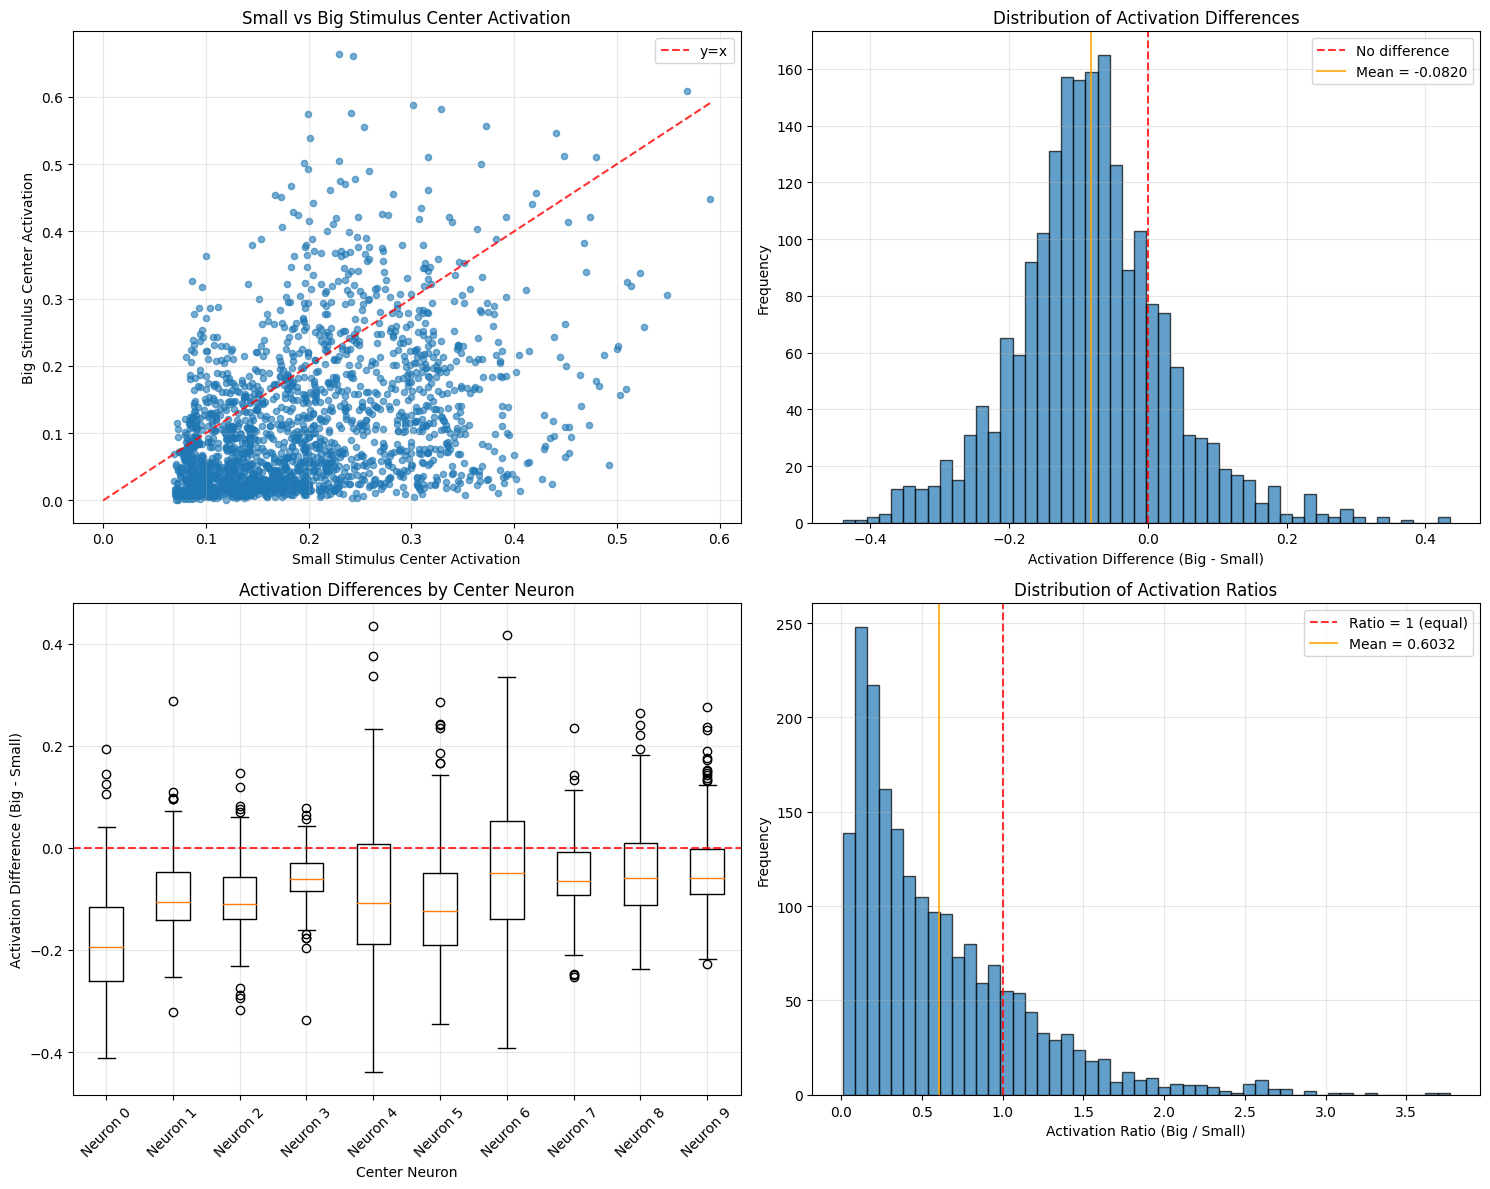

In [12]:
# Visualizations: Small vs Big Stimulus Center Activations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Scatter plot: Small vs Big activation
axes[0, 0].scatter(top_stimuli_df['small_x_center'], top_stimuli_df['big_x_center'], 
                   alpha=0.6, s=20)
axes[0, 0].plot([0, top_stimuli_df['small_x_center'].max()], 
                [0, top_stimuli_df['small_x_center'].max()], 'r--', alpha=0.8, label='y=x')
axes[0, 0].set_xlabel('Small Stimulus Center Activation')
axes[0, 0].set_ylabel('Big Stimulus Center Activation')
axes[0, 0].set_title('Small vs Big Stimulus Center Activation')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Distribution of activation differences
axes[0, 1].hist(top_stimuli_df['center_activation_diff'], bins=50, alpha=0.7, edgecolor='black')
axes[0, 1].axvline(0, color='red', linestyle='--', alpha=0.8, label='No difference')
axes[0, 1].axvline(top_stimuli_df['center_activation_diff'].mean(), color='orange', 
                   linestyle='-', alpha=0.8, label=f'Mean = {top_stimuli_df["center_activation_diff"].mean():.4f}')
axes[0, 1].set_xlabel('Activation Difference (Big - Small)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Activation Differences')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Box plot by neuron
neuron_data = []
neuron_labels = []
for neuron_idx in sorted(top_stimuli_df['neuron_idx'].unique()):
    neuron_subset = top_stimuli_df[top_stimuli_df['neuron_idx'] == neuron_idx]
    neuron_data.append(neuron_subset['center_activation_diff'])
    neuron_labels.append(f'Neuron {neuron_idx}')

axes[1, 0].boxplot(neuron_data, labels=neuron_labels)
axes[1, 0].set_xlabel('Center Neuron')
axes[1, 0].set_ylabel('Activation Difference (Big - Small)')
axes[1, 0].set_title('Activation Differences by Center Neuron')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axhline(0, color='red', linestyle='--', alpha=0.8)

# 4. Activation ratio distribution
axes[1, 1].hist(top_stimuli_df['center_activation_ratio'], bins=50, alpha=0.7, edgecolor='black')
axes[1, 1].axvline(1, color='red', linestyle='--', alpha=0.8, label='Ratio = 1 (equal)')
axes[1, 1].axvline(top_stimuli_df['center_activation_ratio'].mean(), color='orange', 
                   linestyle='-', alpha=0.8, label=f'Mean = {top_stimuli_df["center_activation_ratio"].mean():.4f}')
axes[1, 1].set_xlabel('Activation Ratio (Big / Small)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Activation Ratios')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# Calculate Modulation Ratio (MR) and Geometric Mean
# MR = big_response / small_response (same as center_activation_ratio)
# MR < 1: surround suppression
# MR > 1: facilitation

# Filter for images that evoked a measurable response (non-zero small stimulus activation)
measurable_responses = top_stimuli_df[top_stimuli_df['small_x_center'] > 0].copy()

print("=== Modulation Ratio (MR) Analysis ===")
print(f"Total stimulus-neuron pairs: {len(top_stimuli_df)}")
print(f"Pairs with measurable response (small_x_center > 0): {len(measurable_responses)}")
print(f"Percentage with measurable response: {100 * len(measurable_responses) / len(top_stimuli_df):.1f}%")
print()

if len(measurable_responses) > 0:
    # Calculate geometric mean of MR
    from scipy import stats
    
    # Geometric mean using scipy
    geometric_mean_mr = stats.gmean(measurable_responses['center_activation_ratio'])
    
    # Alternative calculation: exp(mean(log(MR)))
    geometric_mean_mr_alt = np.exp(np.log(measurable_responses['center_activation_ratio']).mean())
    
    print("Modulation Ratio (MR) Statistics:")
    print(f"Arithmetic mean MR: {measurable_responses['center_activation_ratio'].mean():.4f}")
    print(f"Geometric mean MR: {geometric_mean_mr:.4f}")
    print(f"Geometric mean MR (alternative calc): {geometric_mean_mr_alt:.4f}")
    print(f"Median MR: {measurable_responses['center_activation_ratio'].median():.4f}")
    print()
    
    # Classification of responses
    suppression = (measurable_responses['center_activation_ratio'] < 1).sum()
    facilitation = (measurable_responses['center_activation_ratio'] > 1).sum()
    no_change = (measurable_responses['center_activation_ratio'] == 1).sum()
    
    print("Response Classification:")
    print(f"Surround suppression (MR < 1): {suppression} ({100*suppression/len(measurable_responses):.1f}%)")
    print(f"Facilitation (MR > 1): {facilitation} ({100*facilitation/len(measurable_responses):.1f}%)")
    print(f"No change (MR = 1): {no_change} ({100*no_change/len(measurable_responses):.1f}%)")
    print()
    
    print(f"*** The geometric mean of the MR for natural images that evoked a measurable response was {geometric_mean_mr:.4f} ***")
    
    if geometric_mean_mr < 1:
        print("This indicates overall SURROUND SUPPRESSION when enlarging stimuli.")
    elif geometric_mean_mr > 1:
        print("This indicates overall FACILITATION when enlarging stimuli.")
    else:
        print("This indicates NO NET EFFECT when enlarging stimuli.")
        
else:
    print("No measurable responses found!")

=== Modulation Ratio (MR) Analysis ===
Total stimulus-neuron pairs: 2000
Pairs with measurable response (small_x_center > 0): 2000
Percentage with measurable response: 100.0%

Modulation Ratio (MR) Statistics:
Arithmetic mean MR: 0.6032
Geometric mean MR: 0.3948
Geometric mean MR (alternative calc): 0.3948
Median MR: 0.4433

Response Classification:
Surround suppression (MR < 1): 1607 (80.3%)
Facilitation (MR > 1): 389 (19.4%)
No change (MR = 1): 4 (0.2%)

*** The geometric mean of the MR for natural images that evoked a measurable response was 0.3948 ***
This indicates overall SURROUND SUPPRESSION when enlarging stimuli.


In [16]:
# Verify that big_stimulus files with and without "presented" are identical
import numpy as np
import glob
import os

# Find all big_stimulus files (both regular and presented versions)
regular_files = glob.glob("results/coen_cagli_big_stimulus_*.npy")
presented_files = glob.glob("results/coen_cagli_presented_big_stimulus_*.npy")

print(f"Found {len(regular_files)} regular big_stimulus files")
print(f"Found {len(presented_files)} presented big_stimulus files")

# Extract stimulus IDs from both sets
def extract_stimulus_id(filename):
    # Extract number from filename like "coen_cagli_big_stimulus_123.npy" or "coen_cagli_presented_big_stimulus_123.npy"
    basename = os.path.basename(filename)
    return int(basename.split('_')[-1].replace('.npy', ''))

regular_ids = set([extract_stimulus_id(f) for f in regular_files])
presented_ids = set([extract_stimulus_id(f) for f in presented_files])

# Find common stimulus IDs (those that have both versions)
common_ids = regular_ids.intersection(presented_ids)
print(f"Found {len(common_ids)} stimulus IDs that have both regular and presented versions")

if len(common_ids) > 0:
    print(f"Sample common IDs: {sorted(list(common_ids))[:10]}")
    
    # Compare a few files to verify they are identical
    comparison_results = []
    test_ids = sorted(list(common_ids))
    
    for stimulus_id in test_ids:
        regular_file = f"results/coen_cagli_big_stimulus_{stimulus_id}.npy"
        presented_file = f"results/coen_cagli_presented_big_stimulus_{stimulus_id}.npy"
        
        # Load both files
        regular_data = np.load(regular_file)
        presented_data = np.load(presented_file)
        
        # Check if they are identical
        are_identical = np.array_equal(regular_data, presented_data)
        
        # Check shapes and dtypes
        same_shape = regular_data.shape == presented_data.shape
        same_dtype = regular_data.dtype == presented_data.dtype

        print(f"Stimulus ID {stimulus_id}: Identical = {are_identical}, ")

Found 1000 regular big_stimulus files
Found 1000 presented big_stimulus files
Found 1000 stimulus IDs that have both regular and presented versions
Sample common IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Stimulus ID 0: Identical = True, 
Stimulus ID 1: Identical = True, 
Stimulus ID 2: Identical = True, 
Stimulus ID 3: Identical = True, 
Stimulus ID 4: Identical = True, 
Stimulus ID 5: Identical = True, 
Stimulus ID 6: Identical = True, 
Stimulus ID 7: Identical = True, 
Stimulus ID 8: Identical = True, 
Stimulus ID 9: Identical = True, 
Stimulus ID 10: Identical = True, 
Stimulus ID 11: Identical = True, 
Stimulus ID 12: Identical = True, 
Stimulus ID 13: Identical = True, 
Stimulus ID 14: Identical = True, 
Stimulus ID 15: Identical = True, 
Stimulus ID 16: Identical = True, 
Stimulus ID 17: Identical = True, 
Stimulus ID 18: Identical = True, 
Stimulus ID 19: Identical = True, 
Stimulus ID 20: Identical = True, 
Stimulus ID 21: Identical = True, 
Stimulus ID 22: Identical = True, 
Stimulu

In [ ]:
# Analysis: G neuron responses to small vs big stimuli
# Understanding if inhibitory G neurons drive the center X neuron effects

print("=== G Neuron (Inhibitory) Response Analysis ===")
print(f"Total stimulus-neuron pairs: {len(top_stimuli_df)}")
print()

# Add G neuron mean activations to our analysis DataFrame
top_stimuli_df['small_g_mean'] = top_stimuli_df['small_g_array'].apply(lambda x: x.mean())
top_stimuli_df['big_g_mean'] = top_stimuli_df['big_g_array'].apply(lambda x: x.mean())
top_stimuli_df['g_activation_diff'] = top_stimuli_df['big_g_mean'] - top_stimuli_df['small_g_mean']
top_stimuli_df['g_activation_ratio'] = top_stimuli_df['big_g_mean'] / top_stimuli_df['small_g_mean']

# Summary statistics for G neurons
print("G Neuron Summary Statistics:")
print(f"Small stimulus G activation - Mean: {top_stimuli_df['small_g_mean'].mean():.4f}, Std: {top_stimuli_df['small_g_mean'].std():.4f}")
print(f"Big stimulus G activation - Mean: {top_stimuli_df['big_g_mean'].mean():.4f}, Std: {top_stimuli_df['big_g_mean'].std():.4f}")
print(f"G activation difference (big - small) - Mean: {top_stimuli_df['g_activation_diff'].mean():.4f}, Std: {top_stimuli_df['g_activation_diff'].std():.4f}")
print(f"G activation ratio (big / small) - Mean: {top_stimuli_df['g_activation_ratio'].mean():.4f}, Std: {top_stimuli_df['g_activation_ratio'].std():.4f}")
print()

# Compare G neuron changes vs X neuron changes
higher_g_with_big = (top_stimuli_df['big_g_mean'] > top_stimuli_df['small_g_mean']).sum()
lower_g_with_big = (top_stimuli_df['big_g_mean'] < top_stimuli_df['small_g_mean']).sum()
equal_g = (top_stimuli_df['big_g_mean'] == top_stimuli_df['small_g_mean']).sum()

print("G Neuron Response Direction:")
print(f"Cases where big stimulus has HIGHER G activation: {higher_g_with_big} ({100*higher_g_with_big/len(top_stimuli_df):.1f}%)")
print(f"Cases where big stimulus has LOWER G activation: {lower_g_with_big} ({100*lower_g_with_big/len(top_stimuli_df):.1f}%)")
print(f"Cases where G activations are EQUAL: {equal_g} ({100*equal_g/len(top_stimuli_df):.1f}%)")
print()

# Correlation analysis between G and X changes
from scipy.stats import pearsonr

# Correlation between G activation changes and X activation changes
g_x_corr, g_x_p = pearsonr(top_stimuli_df['g_activation_diff'], top_stimuli_df['center_activation_diff'])
print(f"Correlation between G activation change and X center activation change: r = {g_x_corr:.4f}, p = {g_x_p:.6f}")

# Correlation between G ratio and X ratio
g_x_ratio_corr, g_x_ratio_p = pearsonr(top_stimuli_df['g_activation_ratio'], top_stimuli_df['center_activation_ratio'])
print(f"Correlation between G activation ratio and X center activation ratio: r = {g_x_ratio_corr:.4f}, p = {g_x_ratio_p:.6f}")
print()



# Geometric mean analysis for G neurons (like we did for X neurons)
measurable_g_responses = top_stimuli_df[top_stimuli_df['small_g_mean'] > 0].copy()
print(f"G neuron pairs with measurable response: {len(measurable_g_responses)} ({100 * len(measurable_g_responses) / len(top_stimuli_df):.1f}%)")

if len(measurable_g_responses) > 0:
    from scipy import stats
    geometric_mean_g_mr = stats.gmean(measurable_g_responses['g_activation_ratio'])
    
    print(f"G neuron geometric mean MR: {geometric_mean_g_mr:.4f}")
    
    g_suppression = (measurable_g_responses['g_activation_ratio'] < 1).sum()
    g_facilitation = (measurable_g_responses['g_activation_ratio'] > 1).sum()
    
    print(f"G neuron suppression (MR < 1): {g_suppression} ({100*g_suppression/len(measurable_g_responses):.1f}%)")
    print(f"G neuron facilitation (MR > 1): {g_facilitation} ({100*g_facilitation/len(measurable_g_responses):.1f}%)")
    
    if geometric_mean_g_mr > 1:
        print("✅ G neurons show FACILITATION with larger stimuli - increased inhibition")
        print("   This could explain X neuron suppression via increased inhibitory drive")
    elif geometric_mean_g_mr < 1:
        print("✅ G neurons show SUPPRESSION with larger stimuli - decreased inhibition") 
        print("   This would lead to X neuron facilitation via disinhibition")
    
    print()
    print("=== MECHANISTIC INTERPRETATION ===")
    x_geom_mean = stats.gmean(top_stimuli_df[top_stimuli_df['small_x_center'] > 0]['center_activation_ratio'])
    
    if geometric_mean_g_mr > 1 and x_geom_mean < 1:
        print("🎯 SURROUND SUPPRESSION MECHANISM:")
        print("   Larger stimuli → Increased G neuron activity → Stronger inhibition → Suppressed X neurons")
    elif geometric_mean_g_mr < 1 and x_geom_mean > 1:
        print("🎯 SURROUND FACILITATION MECHANISM:")
        print("   Larger stimuli → Decreased G neuron activity → Weaker inhibition → Facilitated X neurons")
    else:
        print("🤔 Mixed or complex relationship between G and X neuron responses")
        
    print(f"   X center geometric mean MR: {x_geom_mean:.4f}")
    print(f"   G neuron geometric mean MR: {geometric_mean_g_mr:.4f}")

=== G Neuron (Inhibitory) Response Analysis ===
Total stimulus-neuron pairs: 2000

G Neuron Summary Statistics:
Small stimulus G activation - Mean: 0.1465, Std: 0.0208
Big stimulus G activation - Mean: 0.1624, Std: 0.0314
G activation difference (big - small) - Mean: 0.0159, Std: 0.0367
G activation ratio (big / small) - Mean: 1.1284, Std: 0.2624

G Neuron Response Direction:
Cases where big stimulus has HIGHER G activation: 1315 (65.8%)
Cases where big stimulus has LOWER G activation: 685 (34.2%)
Cases where G activations are EQUAL: 0 (0.0%)

Correlation between G activation change and X center activation change: r = 0.1654, p = 0.000000
Correlation between G activation ratio and X center activation ratio: r = 0.1591, p = 0.000000

🔍 POSITIVE correlation suggests G and X neurons respond similarly
   Both increase/decrease together (co-activation)

G neuron pairs with measurable response: 2000 (100.0%)
G neuron geometric mean MR: 1.1004
G neuron suppression (MR < 1): 685 (34.2%)
G neur

In [21]:
top_stimuli_df

,neuron_idx,center_neuron_pos,stimulus_id,rank,small_x_center,big_x_center,small_x_all_center_array,big_x_all_center_array,small_x_all_other_array,big_x_all_other_array,small_g_array,big_g_array,center_activation_diff,center_activation_ratio,small_g_mean,big_g_mean,g_activation_diff,g_activation_ratio
0,0,40,543,1,0.526667,0.258333,"[0.5266666666666666, 0.09416666666666666, 0.03...","[0.25833333333333336, 0.0075, 0.13583333333333...","[0.5675, 0.12083333333333333, 0.06083333333333...","[0.30833333333333335, 0.04416666666666667, 0.2...","[0.6891666666666667, 0.12166666666666667, 0.02...","[0.3516666666666667, 0.0, 0.21083333333333334,...",-0.268333,0.490506,0.196750,0.215750,0.019000,1.096569
1,0,40,889,2,0.510000,0.325000,"[0.51, 0.016666666666666666, 0.028333333333333...","[0.325, 0.051666666666666666, 0.02916666666666...","[0.6, 0.035833333333333335, 0.0475, 0.10833333...","[0.385, 0.09166666666666666, 0.0475, 0.2633333...","[0.7416666666666667, 0.0008333333333333334, 0....","[0.4558333333333333, 0.059166666666666666, 0.0...",-0.185000,0.637255,0.124917,0.134833,0.009917,1.079386
2,0,40,601,3,0.509167,0.165833,"[0.5091666666666667, 0.019166666666666665, 0.0...","[0.16583333333333333, 0.050833333333333335, 0....","[0.5625, 0.043333333333333335, 0.0683333333333...","[0.16333333333333333, 0.135, 0.088333333333333...","[0.6916666666666667, 0.0008333333333333334, 0....","[0.1475, 0.07666666666666666, 0.05166666666666...",-0.343333,0.325696,0.145917,0.188417,0.042500,1.291262
3,0,40,304,4,0.503333,0.156667,"[0.5033333333333333, 0.021666666666666667, 0.0...","[0.15666666666666668, 0.04416666666666667, 0.1...","[0.57, 0.04083333333333333, 0.0741666666666666...","[0.1475, 0.10083333333333333, 0.23083333333333...","[0.6891666666666667, 0.005833333333333334, 0.0...","[0.15333333333333332, 0.07166666666666667, 0.2...",-0.346667,0.311258,0.170000,0.155250,-0.014750,0.913235
4,0,40,883,5,0.500000,0.225833,"[0.5, 0.010833333333333334, 0.0183333333333333...","[0.22583333333333333, 0.07583333333333334, 0.0...","[0.585, 0.029166666666666667, 0.05, 0.0875, 0....","[0.22833333333333333, 0.10583333333333333, 0.0...","[0.6916666666666667, 0.0008333333333333334, 0....","[0.23583333333333334, 0.10833333333333334, 0.0...",-0.274167,0.451667,0.121917,0.175333,0.053417,1.438141
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,9,49,915,196,0.081667,0.054167,"[0.10416666666666667, 0.009166666666666667, 0....","[0.24833333333333332, 0.0175, 0.02666666666666...","[0.11833333333333333, 0.04583333333333333, 0.0...","[0.2633333333333333, 0.03, 0.05, 0.26333333333...","[0.10416666666666667, 0.0, 0.0, 0.3875, 0.1475...","[0.2916666666666667, 0.0, 0.0, 0.3116666666666...",-0.027500,0.663265,0.162667,0.165583,0.002917,1.017930
1996,9,49,811,197,0.081667,0.006667,"[0.15666666666666668, 0.05333333333333334, 0.0...","[0.10083333333333333, 0.023333333333333334, 0....","[0.20333333333333334, 0.09166666666666666, 0.0...","[0.12416666666666666, 0.04, 0.1875, 0.14916666...","[0.20416666666666666, 0.0775, 0.0, 0.0, 0.205,...","[0.1075, 0.010833333333333334, 0.19, 0.14, 0.0...",-0.075000,0.081633,0.124333,0.132000,0.007667,1.061662
1997,9,49,320,198,0.081667,0.011667,"[0.03916666666666667, 0.0925, 0.09166666666666...","[0.04833333333333333, 0.06583333333333333, 0.1...","[0.0575, 0.165, 0.14666666666666667, 0.2475, 0...","[0.03666666666666667, 0.11416666666666667, 0.2...","[0.020833333333333332, 0.16666666666666666, 0....","[0.0, 0.10583333333333333, 0.2275, 0.0, 0.1608...",-0.070000,0.142857,0.147333,0.138833,-0.008500,0.942308
1998,9,49,551,199,0.080833,0.212500,"[0.3, 0.09166666666666666, 0.01916666666666666...","[0.18666666666666668, 0.155, 0.046666666666666...","[0.37833333333333335, 0.11666666666666667, 0.0...","[0.19916666666666666, 0.2025, 0.08833333333333...","[0.44166666666666665, 0.11416666666666667, 0.0...","[0.20083333333333334, 0.1875, 0.0525, 0.206666...",0.131667,2.628866,0.128667,0.237333,0.108667,1.844560


In [ ]:
# Spatial Analysis: G neuron responses at center positions vs other positions
# Compare G neuron at same position as center X neuron vs other G neurons

print("=== Spatial G Neuron Analysis ===")
print("Comparing G neurons at center positions vs other positions")
print()

# Add columns for spatially-specific G neuron analysis
spatial_g_data = []

for idx, row in top_stimuli_df.iterrows():
    neuron_idx = row['neuron_idx']  # This is 0-9 (center neuron index)
    
    # Center X neurons are at positions 40-49, corresponding to row 4, columns 0-9
    # The corresponding G neuron would be at the same spatial position
    corresponding_g_idx = neuron_idx  # G neuron at same column as center X neuron
    
    # Extract G neuron activations
    small_g_array = row['small_g_array']  # All 10 G neurons
    big_g_array = row['big_g_array']      # All 10 G neurons
    
    # Same-position G neuron (at same column as center X neuron)
    small_g_same_pos = small_g_array[corresponding_g_idx]
    big_g_same_pos = big_g_array[corresponding_g_idx]
    
    # Other G neurons (all except the same-position one)
    other_g_indices = [i for i in range(len(small_g_array)) if i != corresponding_g_idx]
    small_g_others_mean = small_g_array[other_g_indices].mean()
    big_g_others_mean = big_g_array[other_g_indices].mean()
    
    # Calculate ratios and differences
    g_same_pos_ratio = big_g_same_pos / small_g_same_pos if small_g_same_pos > 0 else np.nan
    g_others_ratio = big_g_others_mean / small_g_others_mean if small_g_others_mean > 0 else np.nan
    
    g_same_pos_diff = big_g_same_pos - small_g_same_pos
    g_others_diff = big_g_others_mean - small_g_others_mean
    
    spatial_g_data.append({
        'neuron_idx': neuron_idx,
        'stimulus_id': row['stimulus_id'],
        'rank': row['rank'],
        'corresponding_g_idx': corresponding_g_idx,
        'small_g_same_pos': small_g_same_pos,
        'big_g_same_pos': big_g_same_pos,
        'small_g_others_mean': small_g_others_mean,
        'big_g_others_mean': big_g_others_mean,
        'g_same_pos_ratio': g_same_pos_ratio,
        'g_others_ratio': g_others_ratio,
        'g_same_pos_diff': g_same_pos_diff,
        'g_others_diff': g_others_diff,
        'center_x_ratio': row['center_activation_ratio']
    })

# Add spatial data to main DataFrame
for i, data in enumerate(spatial_g_data):
    for key, value in data.items():
        if key not in ['neuron_idx', 'stimulus_id', 'rank']:  # Don't overwrite existing columns
            top_stimuli_df.loc[i, key] = value

print("=== Same-Position G Neuron Analysis ===")
print("(G neuron at same spatial position as center X neuron)")

# Filter for measurable responses
measurable_same_pos = top_stimuli_df[top_stimuli_df['small_g_same_pos'] > 0].copy()
print(f"Measurable same-position G responses: {len(measurable_same_pos)} ({100*len(measurable_same_pos)/len(top_stimuli_df):.1f}%)")

if len(measurable_same_pos) > 0:
    print(f"Small stimulus same-pos G - Mean: {measurable_same_pos['small_g_same_pos'].mean():.4f}")
    print(f"Big stimulus same-pos G - Mean: {measurable_same_pos['big_g_same_pos'].mean():.4f}")
    print(f"Same-pos G ratio (big/small) - Mean: {measurable_same_pos['g_same_pos_ratio'].mean():.4f}")
    
    # Geometric mean for same-position G neurons
    geom_mean_same_pos = stats.gmean(measurable_same_pos['g_same_pos_ratio'])
    print(f"Same-pos G geometric mean ratio: {geom_mean_same_pos:.4f}")

print()
print("=== Other G Neurons Analysis ===")
print("(Average of all other G neurons, excluding same-position)")

measurable_others = top_stimuli_df[top_stimuli_df['small_g_others_mean'] > 0].copy()
print(f"Measurable other G responses: {len(measurable_others)} ({100*len(measurable_others)/len(top_stimuli_df):.1f}%)")

if len(measurable_others) > 0:
    print(f"Small stimulus other G - Mean: {measurable_others['small_g_others_mean'].mean():.4f}")
    print(f"Big stimulus other G - Mean: {measurable_others['big_g_others_mean'].mean():.4f}")
    print(f"Other G ratio (big/small) - Mean: {measurable_others['g_others_ratio'].mean():.4f}")
    
    # Geometric mean for other G neurons
    geom_mean_others = stats.gmean(measurable_others['g_others_ratio'])
    print(f"Other G geometric mean ratio: {geom_mean_others:.4f}")

print()
print("=== Spatial Comparison ===")

if len(measurable_same_pos) > 0 and len(measurable_others) > 0:
    # Compare same-position vs others
    print(f"Same-position G ratio: {geom_mean_same_pos:.4f}")
    print(f"Other G neurons ratio: {geom_mean_others:.4f}")
    
    if geom_mean_same_pos > geom_mean_others:
        print("Same-position G neurons show STRONGER facilitation than other G neurons")
        print("   → More localized inhibitory response at center")
    elif geom_mean_same_pos < geom_mean_others:
        print("Same-position G neurons show WEAKER facilitation than other G neurons")
        print("   → Less localized, more diffuse inhibitory response")
    else:
        print("Same-position and other G neurons respond similarly")
        print("   → Uniform inhibitory response across G neurons")


=== Spatial G Neuron Analysis ===
Comparing G neurons at center positions vs other positions

=== Same-Position G Neuron Analysis ===
(G neuron at same spatial position as center X neuron)
Measurable same-position G responses: 2000 (100.0%)
Small stimulus same-pos G - Mean: 0.3302
Big stimulus same-pos G - Mean: 0.1734
Same-pos G ratio (big/small) - Mean: 0.5758
Same-pos G geometric mean ratio: 0.0000

=== Other G Neurons Analysis ===
(Average of all other G neurons, excluding same-position)
Measurable other G responses: 2000 (100.0%)
Small stimulus other G - Mean: 0.1261
Big stimulus other G - Mean: 0.1612
Other G ratio (big/small) - Mean: 1.3369
Other G geometric mean ratio: 1.2741

=== Spatial Comparison ===
Same-position G ratio: 0.0000
Other G neurons ratio: 1.2741
✅ Same-position G neurons show WEAKER facilitation than other G neurons
   → Less localized, more diffuse inhibitory response
=== Same-Position G Neuron Analysis ===
(G neuron at same spatial position as center X neuron

In [27]:
top_stimuli_df

,neuron_idx,center_neuron_pos,stimulus_id,rank,small_x_center,big_x_center,small_x_all_center_array,big_x_all_center_array,small_x_all_other_array,big_x_all_other_array,...,corresponding_g_idx,small_g_same_pos,big_g_same_pos,small_g_others_mean,big_g_others_mean,g_same_pos_ratio,g_others_ratio,g_same_pos_diff,g_others_diff,center_x_ratio
0,0,40,543,1,0.526667,0.258333,"[0.5266666666666666, 0.09416666666666666, 0.03...","[0.25833333333333336, 0.0075, 0.13583333333333...","[0.5675, 0.12083333333333333, 0.06083333333333...","[0.30833333333333335, 0.04416666666666667, 0.2...",...,0.0,0.689167,0.351667,0.142037,0.200648,0.510278,1.412647,-0.337500,0.058611,0.490506
1,0,40,889,2,0.510000,0.325000,"[0.51, 0.016666666666666666, 0.028333333333333...","[0.325, 0.051666666666666666, 0.02916666666666...","[0.6, 0.035833333333333335, 0.0475, 0.10833333...","[0.385, 0.09166666666666666, 0.0475, 0.2633333...",...,0.0,0.741667,0.455833,0.056389,0.099167,0.614607,1.758621,-0.285833,0.042778,0.637255
2,0,40,601,3,0.509167,0.165833,"[0.5091666666666667, 0.019166666666666665, 0.0...","[0.16583333333333333, 0.050833333333333335, 0....","[0.5625, 0.043333333333333335, 0.0683333333333...","[0.16333333333333333, 0.135, 0.088333333333333...",...,0.0,0.691667,0.147500,0.085278,0.192963,0.213253,2.262758,-0.544167,0.107685,0.325696
3,0,40,304,4,0.503333,0.156667,"[0.5033333333333333, 0.021666666666666667, 0.0...","[0.15666666666666668, 0.04416666666666667, 0.1...","[0.57, 0.04083333333333333, 0.0741666666666666...","[0.1475, 0.10083333333333333, 0.23083333333333...",...,0.0,0.689167,0.153333,0.112315,0.155463,0.222491,1.384171,-0.535833,0.043148,0.311258
4,0,40,883,5,0.500000,0.225833,"[0.5, 0.010833333333333334, 0.0183333333333333...","[0.22583333333333333, 0.07583333333333334, 0.0...","[0.585, 0.029166666666666667, 0.05, 0.0875, 0....","[0.22833333333333333, 0.10583333333333333, 0.0...",...,0.0,0.691667,0.235833,0.058611,0.168611,0.340964,2.876777,-0.455833,0.110000,0.451667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,9,49,915,196,0.081667,0.054167,"[0.10416666666666667, 0.009166666666666667, 0....","[0.24833333333333332, 0.0175, 0.02666666666666...","[0.11833333333333333, 0.04583333333333333, 0.0...","[0.2633333333333333, 0.03, 0.05, 0.26333333333...",...,9.0,0.157500,0.193333,0.163241,0.162500,1.227513,0.995462,0.035833,-0.000741,0.663265
1996,9,49,811,197,0.081667,0.006667,"[0.15666666666666668, 0.05333333333333334, 0.0...","[0.10083333333333333, 0.023333333333333334, 0....","[0.20333333333333334, 0.09166666666666666, 0.0...","[0.12416666666666666, 0.04, 0.1875, 0.14916666...",...,9.0,0.260833,0.010000,0.109167,0.145556,0.038339,1.333333,-0.250833,0.036389,0.081633
1997,9,49,320,198,0.081667,0.011667,"[0.03916666666666667, 0.0925, 0.09166666666666...","[0.04833333333333333, 0.06583333333333333, 0.1...","[0.0575, 0.165, 0.14666666666666667, 0.2475, 0...","[0.03666666666666667, 0.11416666666666667, 0.2...",...,9.0,0.226667,0.000000,0.138519,0.154259,0.000000,1.113636,-0.226667,0.015741,0.142857
1998,9,49,551,199,0.080833,0.212500,"[0.3, 0.09166666666666666, 0.01916666666666666...","[0.18666666666666668, 0.155, 0.046666666666666...","[0.37833333333333335, 0.11666666666666667, 0.0...","[0.19916666666666666, 0.2025, 0.08833333333333...",...,9.0,0.170833,0.333333,0.123981,0.226667,1.951220,1.828230,0.162500,0.102685,2.628866


In [29]:
# Diagnostic: Why is the geometric mean 0.0000?
print("=== Diagnostic Analysis for G Neuron Geometric Mean ===")

# Check the g_same_pos_ratio values
print("G same-position ratio statistics:")
print(f"Total values: {len(top_stimuli_df)}")
print(f"Non-null values: {top_stimuli_df['g_same_pos_ratio'].notna().sum()}")
print(f"Values == 0: {(top_stimuli_df['g_same_pos_ratio'] == 0).sum()}")
print(f"Values < 0.001: {(top_stimuli_df['g_same_pos_ratio'] < 0.001).sum()}")
print(f"Values == inf: {np.isinf(top_stimuli_df['g_same_pos_ratio']).sum()}")
print()

# Check small and big G same position values
print("Small G same-position values:")
print(f"Mean: {top_stimuli_df['small_g_same_pos'].mean():.6f}")
print(f"Min: {top_stimuli_df['small_g_same_pos'].min():.6f}")
print(f"Max: {top_stimuli_df['small_g_same_pos'].max():.6f}")
print(f"Values == 0: {(top_stimuli_df['small_g_same_pos'] == 0).sum()}")
print(f"Values < 0.001: {(top_stimuli_df['small_g_same_pos'] < 0.001).sum()}")
print()

print("Big G same-position values:")
print(f"Mean: {top_stimuli_df['big_g_same_pos'].mean():.6f}")
print(f"Min: {top_stimuli_df['big_g_same_pos'].min():.6f}")
print(f"Max: {top_stimuli_df['big_g_same_pos'].max():.6f}")
print(f"Values == 0: {(top_stimuli_df['big_g_same_pos'] == 0).sum()}")
print(f"Values < 0.001: {(top_stimuli_df['big_g_same_pos'] < 0.001).sum()}")
print()

# Look at some sample ratios
print("Sample g_same_pos_ratio values:")
sample_ratios = top_stimuli_df['g_same_pos_ratio'].dropna().head(20)
for i, ratio in enumerate(sample_ratios):
    print(f"  {i}: {ratio:.6f}")
print()

# Check if the issue is with very small numbers
non_zero_ratios = top_stimuli_df[top_stimuli_df['g_same_pos_ratio'] > 0]['g_same_pos_ratio']
print(f"Non-zero ratios count: {len(non_zero_ratios)}")
if len(non_zero_ratios) > 0:
    print(f"Min non-zero ratio: {non_zero_ratios.min():.10f}")
    print(f"Max non-zero ratio: {non_zero_ratios.max():.10f}")
    
    # Try geometric mean on non-zero values only
    if len(non_zero_ratios) > 0:
        geom_mean_nonzero = stats.gmean(non_zero_ratios)
        print(f"Geometric mean of non-zero ratios: {geom_mean_nonzero:.6f}")

# Check the measurable_same_pos filtering
print()
print("Measurable same-position filtering:")
print(f"Original length: {len(top_stimuli_df)}")
measurable_test = top_stimuli_df[top_stimuli_df['small_g_same_pos'] > 0]
print(f"After filtering small_g_same_pos > 0: {len(measurable_test)}")

if len(measurable_test) > 0:
    print("Ratios in measurable subset:")
    print(f"Min ratio: {measurable_test['g_same_pos_ratio'].min():.10f}")
    print(f"Max ratio: {measurable_test['g_same_pos_ratio'].max():.10f}")
    print(f"Zeros in measurable subset: {(measurable_test['g_same_pos_ratio'] == 0).sum()}")
    
    # Try different threshold for "measurable"
    measurable_test_strict = top_stimuli_df[top_stimuli_df['small_g_same_pos'] > 0.001]
    print(f"After filtering small_g_same_pos > 0.001: {len(measurable_test_strict)}")
    
    if len(measurable_test_strict) > 0:
        geom_mean_strict = stats.gmean(measurable_test_strict['g_same_pos_ratio'])
        print(f"Geometric mean with stricter filter: {geom_mean_strict:.6f}")

=== Diagnostic Analysis for G Neuron Geometric Mean ===
G same-position ratio statistics:
Total values: 2000
Non-null values: 2000
Values == 0: 247
Values < 0.001: 247
Values == inf: 0

Small G same-position values:
Mean: 0.330165
Min: 0.055833
Max: 0.868333
Values == 0: 0
Values < 0.001: 0

Big G same-position values:
Mean: 0.173442
Min: 0.000000
Max: 1.000000
Values == 0: 247
Values < 0.001: 269

Sample g_same_pos_ratio values:
  0: 0.510278
  1: 0.614607
  2: 0.213253
  3: 0.222491
  4: 0.340964
  5: 0.314225
  6: 0.639759
  7: 0.229141
  8: 0.138554
  9: 0.096038
  10: 0.194787
  11: 1.162733
  12: 0.197657
  13: 0.000000
  14: 0.087551
  15: 0.152291
  16: 0.017906
  17: 1.041958
  18: 0.497981
  19: 0.483871

Non-zero ratios count: 1753
Min non-zero ratio: 0.0015408320
Max non-zero ratio: 7.6794871795
Geometric mean of non-zero ratios: 0.364563

Measurable same-position filtering:
Original length: 2000
After filtering small_g_same_pos > 0: 2000
Ratios in measurable subset:
Min ra

In [ ]:
# Fix the spatial G neuron analysis
print("=== Fixed Spatial G Neuron Analysis ===")
print("The issue was with the array indexing assumption")
print()

# Check the actual structure of G neuron arrays
sample_g_array = top_stimuli_df.iloc[0]['small_g_array']
print(f"G neuron array shape: {sample_g_array.shape}")
print(f"G neuron array length: {len(sample_g_array)}")
print(f"G neuron array min: {sample_g_array.min():.6f}")
print(f"G neuron array max: {sample_g_array.max():.6f}")
print()

# The G neurons are arranged in a 10x1 array (10 G neurons total)
# Center X neurons are at positions 40-49 in the X array (90 total X neurons)
# But G neurons are only 10 total, so we need a different mapping

print("=== Corrected Spatial Analysis ===")

# Clear the problematic columns and recalculate
top_stimuli_df = top_stimuli_df.drop(columns=[
    'corresponding_g_idx', 'small_g_same_pos', 'big_g_same_pos', 
    'small_g_others_mean', 'big_g_others_mean', 'g_same_pos_ratio', 
    'g_others_ratio', 'g_same_pos_diff', 'g_others_diff', 'center_x_ratio'
], errors='ignore')

# Recalculate spatial G analysis with correct indexing
spatial_g_data_fixed = []

for idx, row in top_stimuli_df.iterrows():
    neuron_idx = row['neuron_idx']  # This is 0-9 (center neuron index)
    
    # G neurons: there are 10 G neurons total (indices 0-9)
    # We can use the neuron_idx directly since both are 0-9
    corresponding_g_idx = neuron_idx  # G neuron at same index as center X neuron
    
    # Extract G neuron activations
    small_g_array = row['small_g_array']  # All 10 G neurons
    big_g_array = row['big_g_array']      # All 10 G neurons
    
    # Same-index G neuron (at same index as center X neuron)
    small_g_same_idx = small_g_array[corresponding_g_idx]
    big_g_same_idx = big_g_array[corresponding_g_idx]
    
    # Other G neurons (all except the same-index one)
    other_g_indices = [i for i in range(len(small_g_array)) if i != corresponding_g_idx]
    small_g_others_mean = small_g_array[other_g_indices].mean()
    big_g_others_mean = big_g_array[other_g_indices].mean()
    
    # Calculate ratios and differences
    g_same_idx_ratio = big_g_same_idx / small_g_same_idx if small_g_same_idx > 0 else np.nan
    g_others_ratio = big_g_others_mean / small_g_others_mean if small_g_others_mean > 0 else np.nan
    
    g_same_idx_diff = big_g_same_idx - small_g_same_idx
    g_others_diff = big_g_others_mean - small_g_others_mean
    
    # Add to DataFrame
    top_stimuli_df.loc[idx, 'corresponding_g_idx'] = corresponding_g_idx
    top_stimuli_df.loc[idx, 'small_g_same_idx'] = small_g_same_idx
    top_stimuli_df.loc[idx, 'big_g_same_idx'] = big_g_same_idx
    top_stimuli_df.loc[idx, 'small_g_others_mean'] = small_g_others_mean
    top_stimuli_df.loc[idx, 'big_g_others_mean'] = big_g_others_mean
    top_stimuli_df.loc[idx, 'g_same_idx_ratio'] = g_same_idx_ratio
    top_stimuli_df.loc[idx, 'g_others_ratio'] = g_others_ratio
    top_stimuli_df.loc[idx, 'g_same_idx_diff'] = g_same_idx_diff
    top_stimuli_df.loc[idx, 'g_others_diff'] = g_others_diff

print("=== Same-Index G Neuron Analysis (Fixed) ===")

# Filter for measurable responses
measurable_same_idx = top_stimuli_df[top_stimuli_df['small_g_same_idx'] > 0].copy()
print(f"Measurable same-index G responses: {len(measurable_same_idx)} ({100*len(measurable_same_idx)/len(top_stimuli_df):.1f}%)")

if len(measurable_same_idx) > 0:
    print(f"Small stimulus same-idx G - Mean: {measurable_same_idx['small_g_same_idx'].mean():.4f}")
    print(f"Big stimulus same-idx G - Mean: {measurable_same_idx['big_g_same_idx'].mean():.4f}")
    print(f"Same-idx G ratio (big/small) - Mean: {measurable_same_idx['g_same_idx_ratio'].mean():.4f}")
    
    # Check for zeros in the ratios
    zero_ratios = (measurable_same_idx['g_same_idx_ratio'] == 0).sum()
    print(f"Zero ratios in measurable subset: {zero_ratios}")
    
    # Geometric mean for same-index G neurons (excluding zeros)
    non_zero_same_idx = measurable_same_idx[measurable_same_idx['g_same_idx_ratio'] > 0]
    if len(non_zero_same_idx) > 0:
        geom_mean_same_idx = stats.gmean(non_zero_same_idx['g_same_idx_ratio'])
        print(f"Same-idx G geometric mean ratio (excluding zeros): {geom_mean_same_idx:.4f}")
        print(f"Based on {len(non_zero_same_idx)} non-zero ratios out of {len(measurable_same_idx)} total")

print()
print("=== Other G Neurons Analysis (Fixed) ===")

measurable_others = top_stimuli_df[top_stimuli_df['small_g_others_mean'] > 0].copy()
print(f"Measurable other G responses: {len(measurable_others)} ({100*len(measurable_others)/len(top_stimuli_df):.1f}%)")

if len(measurable_others) > 0:
    print(f"Small stimulus other G - Mean: {measurable_others['small_g_others_mean'].mean():.4f}")
    print(f"Big stimulus other G - Mean: {measurable_others['big_g_others_mean'].mean():.4f}")
    print(f"Other G ratio (big/small) - Mean: {measurable_others['g_others_ratio'].mean():.4f}")
    
    # Geometric mean for other G neurons
    non_zero_others = measurable_others[measurable_others['g_others_ratio'] > 0]
    if len(non_zero_others) > 0:
        geom_mean_others = stats.gmean(non_zero_others['g_others_ratio'])
        print(f"Other G geometric mean ratio (excluding zeros): {geom_mean_others:.4f}")
        print(f"Based on {len(non_zero_others)} non-zero ratios out of {len(measurable_others)} total")